This is a script that calculates the zonal mean of the air temperature (ta)

## **0. Importing functions and packages**

In [1]:
from ta_functions import *

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# **A. NorESM2-LM**

## **1. Getting the ta data from NIRD**

In [2]:
experiments = ['piControl', 'abrupt-4xCO2']

ta_exp_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Amon/ta/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))
    ds = ds.where(ds.ta.notnull())

    yearly_ta = yearly_avg(ds['ta'])
    
    ta_exp_noresm2.append(yearly_ta)

## **2. Turning K --> C**

In [3]:
ta_exp_noresm2_piControl = ta_exp_noresm2[0]-273.15
ta_exp_noresm2_x4CO2 = ta_exp_noresm2[1]-273.15

## **3. Calculating the zonal average for each time slice**

In [23]:
ta_noresm2_zonal_0_30 = (ta_exp_noresm2_x4CO2.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon')
ta_noresm2_zonal_120_150 = (ta_exp_noresm2_x4CO2.isel(year = slice(120, 150))).mean(dim='year').mean(dim='lon')
ta_noresm2_zonal_470_500 = (ta_exp_noresm2_x4CO2.isel(year = slice(470,500))).mean(dim='year').mean(dim='lon')

ta_noresm2_zonal_piControl = (ta_exp_noresm2_piControl.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon')

# turning zero to nan

ta_noresm2_zonal_0_30 = ta_noresm2_zonal_0_30.where(ta_noresm2_zonal_0_30 !=0)
ta_noresm2_zonal_120_150 = ta_noresm2_zonal_120_150.where(ta_noresm2_zonal_120_150 !=0)
ta_noresm2_zonal_470_500 = ta_noresm2_zonal_470_500.where(ta_noresm2_zonal_470_500 !=0)
ta_noresm2_zonal_piControl = ta_noresm2_zonal_piControl.where(ta_noresm2_zonal_piControl !=0)

# **B. IPSL-CM6A-LR**

## **1. Getting the ta data from NIRD**

!!! the piControl path has only 800 years but we need the first 30 anyways.

In [4]:
experiments = ['piControl', 'abrupt-4xCO2']

ta_exp_ipsl = []
sftlf = []

for experiment in experiments:

    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Amon/ta/gr/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))
    ds = ds.where(ds.ta.notnull())
    ds['time'] = to_cftime(ds['time'].values)

    yearly_ta = yearly_avg(ds['ta'])
    
    ta_exp_ipsl.append(yearly_ta)

    # Getting the surface-to-land-fraction while we're at it

    folder_path_land = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/fx/sftlf/gr/latest'

    file_names_land = sorted(os.listdir(folder_path_land))
    
    datasets_land = [xr.open_dataset(os.path.join(folder_path_land, file_name), chunks={'time': 10}) for file_name in file_names_land if file_name.endswith('.nc')]

    sftlf.append(datasets_land)

## **2. Masking**

We need to mask out the land values. Therefore we use the surface to land fraction (sftlf). 

In [8]:
sftlf_ipsl = sftlf[0][0]['sftlf']
#ocean_mask = sftlf_ipsl < 50 
ocean_mask = sftlf_ipsl == 0

ta_exp_ipsl_piControl = ta_exp_ipsl[0].where(ocean_mask)
ta_exp_ipsl_x4CO2 = ta_exp_ipsl[1].where(ocean_mask)

## **3. Turning K --> C**

In [15]:
#ta_exp_ipsl_piControl = ta_exp_ipsl[0].where(ta_exp_ipsl[0] != 0)
#ta_exp_ipsl_x4CO2 = ta_exp_ipsl[1].where(ta_exp_ipsl[0] != 0)

# Convert K → C
ta_exp_ipsl_piControl = ta_exp_ipsl_piControl - 273.15
ta_exp_ipsl_x4CO2 = ta_exp_ipsl_x4CO2 - 273.15

## **4. Calculating the zonal average for each time slice**

In [10]:
ta_ipsl_zonal_0_30 = (ta_exp_ipsl_x4CO2.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon', skipna=True)
ta_ipsl_zonal_120_150 = (ta_exp_ipsl_x4CO2.isel(year = slice(120, 150))).mean(dim='year').mean(dim='lon', skipna=True)
ta_ipsl_zonal_470_500 = (ta_exp_ipsl_x4CO2.isel(year = slice(470,500))).mean(dim='year').mean(dim='lon', skipna=True)
ta_ipsl_zonal_870_900 = (ta_exp_ipsl_x4CO2.isel(year = slice(870,900))).mean(dim='year').mean(dim='lon', skipna=True)

ta_ipsl_zonal_piControl = (ta_exp_ipsl_piControl.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon', skipna=True)

# turning zero to nan

#ta_ipsl_zonal_0_30 = ta_ipsl_zonal_0_30.where(ta_ipsl_zonal_0_30 !=0)
#ta_ipsl_zonal_120_150 = ta_ipsl_zonal_120_150.where(ta_ipsl_zonal_120_150 !=0)
#ta_ipsl_zonal_470_500 = ta_ipsl_zonal_470_500.where(ta_ipsl_zonal_470_500 !=0)
#ta_ipsl_zonal_870_900 = ta_ipsl_zonal_870_900.where(ta_ipsl_zonal_piControl !=0)

#ta_ipsl_zonal_piControl = ta_ipsl_zonal_piControl.where(ta_ipsl_zonal_piControl !=0)

# **C. CESM2**

## **1. Getting the ta data from NIRD**

In [11]:
experiments = ['piControl', 'abrupt-4xCO2']

ta_exp_cesm2 = []
sftlf_cesm2 = []

for experiment in experiments:

    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Amon/ta/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}, decode_cf=True) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))
    ds = ds.where(ds.ta.notnull())

    yearly_ta = yearly_avg(ds['ta'])
    
    ta_exp_cesm2.append(yearly_ta)

    # Getting the surface-to-land-fraction while we're at it

    folder_path_land = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/fx/sftlf/gn/latest'

    file_names_land = sorted(os.listdir(folder_path_land))
    
    datasets_land = [xr.open_dataset(os.path.join(folder_path_land, file_name), chunks={'time': 10}) for file_name in file_names_land if file_name.endswith('.nc')]

    sftlf_cesm2.append(datasets_land)

## **2. Masking**

In [19]:
sftlf_cesm2_m = sftlf_cesm2[1][0]['sftlf']
ocean_mask_cesm2 = sftlf_cesm2_m == 0

ta_exp_cesm2_piControl = ta_exp_cesm2[0]#.where(ocean_mask_cesm2)
ta_exp_cesm2_x4CO2 = ta_exp_cesm2[1]#.where(ocean_mask_cesm2)

## **3. Turning K --> C**

In [20]:
ta_exp_cesm2_piControl = ta_exp_cesm2_piControl - 273.15
ta_exp_cesm2_x4CO2 = ta_exp_cesm2_x4CO2 - 273.15

## **4. Calculating the zonal average for the time slices of interest**

In [21]:
ta_cesm2_zonal_120_150 = (ta_exp_cesm2_x4CO2.isel(year = slice(120, 150))).mean(dim='year').mean(dim='lon', skipna=True)
ta_cesm2_zonal_470_500 = (ta_exp_cesm2_x4CO2.isel(year = slice(470,500))).mean(dim='year').mean(dim='lon', skipna=True)
ta_cesm2_zonal_870_900 = (ta_exp_cesm2_x4CO2.isel(year = slice(870,900))).mean(dim='year').mean(dim='lon', skipna=True)
ta_cesm2_zonal_970_999 = (ta_exp_cesm2_x4CO2.isel(year = slice(970,999))).mean(dim='year').mean(dim='lon', skipna=True)

ta_cesm2_zonal_piControl = (ta_exp_cesm2_piControl.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon', skipna=True)

# turning zero to nan

#ta_cesm2_zonal_120_150 = ta_cesm2_zonal_120_150.where(ta_cesm2_zonal_120_150 > -190)
#ta_cesm2_zonal_470_500 = ta_cesm2_zonal_470_500.where(ta_cesm2_zonal_470_500 > -190)
#ta_cesm2_zonal_870_900 = ta_cesm2_zonal_870_900.where(ta_cesm2_zonal_piControl > -190)
#ta_cesm2_zonal_970_999 = ta_cesm2_zonal_870_900.where(ta_cesm2_zonal_piControl > -190)

#ta_cesm2_zonal_piControl = ta_cesm2_zonal_piControl.where(ta_cesm2_zonal_piControl > -190)

# **D. Plots**

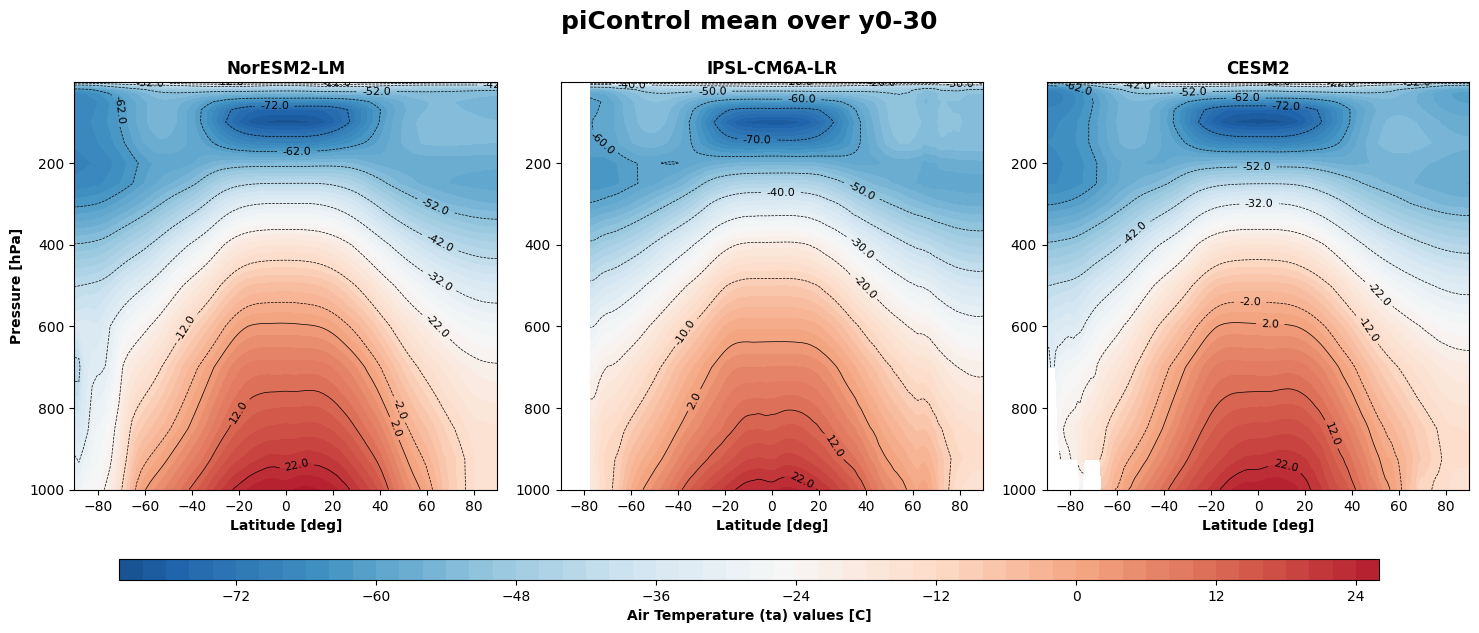

In [24]:
data_piControl_list = [ta_noresm2_zonal_piControl, ta_ipsl_zonal_piControl, ta_cesm2_zonal_piControl]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i in range(0, 3):

    if titles[i]== "NorESM2-LM":        

        lat = ta_noresm2_zonal_piControl.lat
        lev = ta_noresm2_zonal_piControl.plev/100 

    elif titles[i]== "IPSL-CM6A-LR":        

        lat = ta_ipsl_zonal_piControl.lat
        lev = ta_ipsl_zonal_piControl.plev/100 

    else:
        lat = ta_cesm2_zonal_piControl.lat
        lev = ta_cesm2_zonal_piControl.plev/100  
        
    data = data_piControl_list[i]

    #print(data)

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        vmin=-90, vmax=40
    )

    levels = im_pi.levels
    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels[::5],
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels[::5],
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Pressure [hPa]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Air Temperature (ta) values [C]", fontweight='bold')

fig.suptitle("piControl mean over y0-30", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

In [ ]:
# Anomnalies

In [26]:
diff_noresm2_120_150 = (ta_noresm2_zonal_120_150 - ta_noresm2_zonal_piControl).values
diff_noresm2_470_500 = (ta_noresm2_zonal_470_500 - ta_noresm2_zonal_piControl).values

diff_ipsl_120_150 = (ta_ipsl_zonal_120_150 - ta_ipsl_zonal_piControl).values
diff_ipsl_470_500 = (ta_ipsl_zonal_470_500 - ta_ipsl_zonal_piControl).values
diff_ipsl_870_900 = (ta_ipsl_zonal_870_900 - ta_ipsl_zonal_piControl).values

diff_cesm2_120_150 = (ta_cesm2_zonal_120_150 - ta_cesm2_zonal_piControl).values
diff_cesm2_470_500 = (ta_cesm2_zonal_470_500 - ta_cesm2_zonal_piControl).values
diff_cesm2_870_900 = (ta_cesm2_zonal_870_900 - ta_cesm2_zonal_piControl).values
diff_cesm2_970_999 = (ta_cesm2_zonal_970_999 - ta_cesm2_zonal_piControl).values

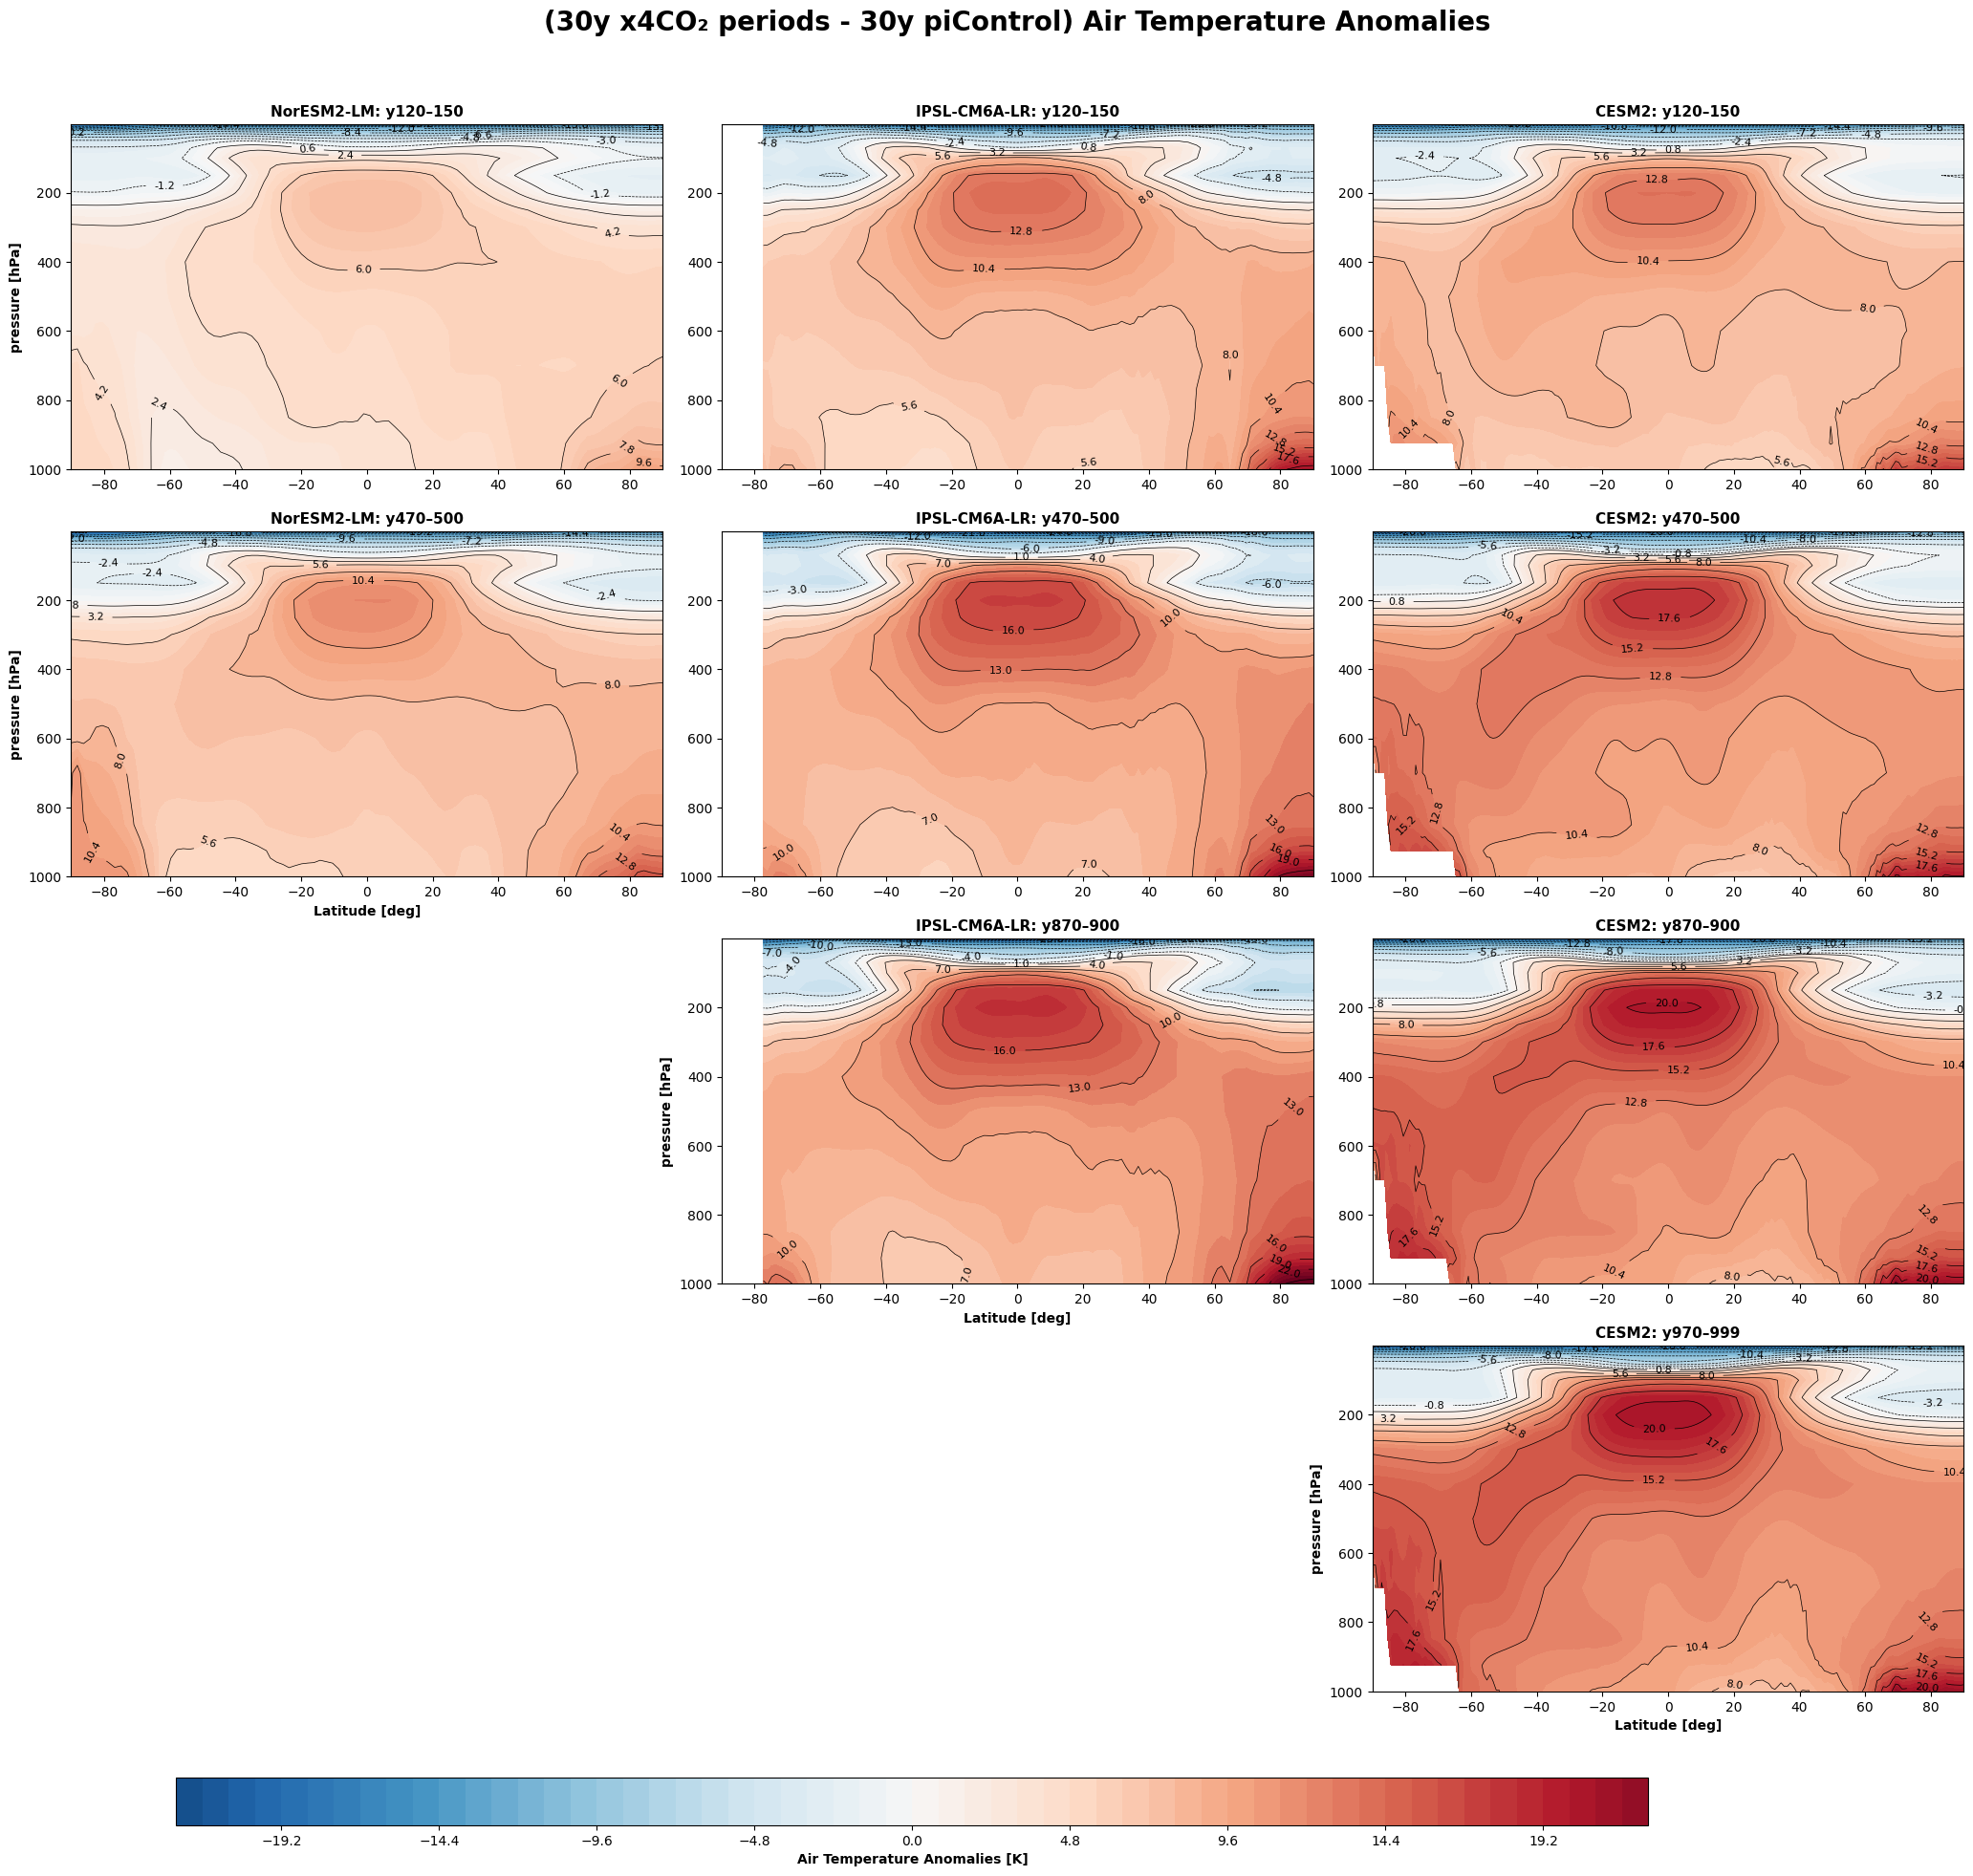

In [23]:
# ---- DATASETS ----
noresm_datasets = [
    (diff_noresm2_120_150,  "NorESM2-LM: y120–150", "noresm2"),
    (diff_noresm2_470_500,  "NorESM2-LM: y470–500", "noresm2"),
]

ipsl_datasets = [
    (diff_ipsl_120_150, "IPSL-CM6A-LR: y120–150", "ipsl"),
    (diff_ipsl_470_500, "IPSL-CM6A-LR: y470–500", "ipsl"),
    (diff_ipsl_870_900, "IPSL-CM6A-LR: y870–900", "ipsl"),
]

cesm_datasets = [
    (diff_cesm2_120_150, "CESM2: y120–150", "cesm2"),
    (diff_cesm2_470_500, "CESM2: y470–500", "cesm2"),
    (diff_cesm2_870_900, "CESM2: y870–900", "cesm2"),
    (diff_cesm2_970_999, "CESM2: y970–999", "cesm2"),
]

all_groups = [noresm_datasets, ipsl_datasets, cesm_datasets]

# Count rows for each column
col_rows = [len(g) for g in all_groups]
max_rows = max(col_rows)


# ---- FIGURE ----
fig = plt.figure(figsize=(22, 20))
gs = fig.add_gridspec(
    nrows=max_rows, ncols=3,
    height_ratios=[1]*max_rows,
    width_ratios=[1, 1, 1]
)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")


# =====================================================================
# PLOTTING LOOP
# =====================================================================

for col, group in enumerate(all_groups):      # loop over 3 columns
    n_panels = len(group)

    # Column 0 (NorESM2) starts at the top
    if col == 0:
        offset = 0
    else:
        offset = (max_rows - n_panels) // 2     # center columns 2 & 3

    for k, (data_anom, panel_title, model) in enumerate(group):

        # ------------------------ LAT & LEVELS ------------------------
        if model == "noresm2":
            lat = ta_noresm2_zonal_piControl.lat
            lev = ta_noresm2_zonal_piControl.plev/100 

        elif model == "ipsl":
            lat = ta_ipsl_zonal_piControl.lat
            lev = ta_ipsl_zonal_piControl.plev/100 

        elif model == "cesm2":
            lat = ta_cesm2_zonal_piControl.lat
            lev = ta_cesm2_zonal_piControl.plev/100  

        # Position in grid (row, column)
        row = offset + k
        ax = fig.add_subplot(gs[row, col])

        # ------------------------ FILLED CONTOURS ------------------------
        im = ax.contourf(
            lat, lev, data_anom,
            levels=60, cmap="RdBu_r",
            vmin=-25, vmax=25
        )
        

        # ------------------------ LINE CONTOURS ------------------------
        levels = im.levels
        neg_levels = levels[levels < 0]
        pos_levels = levels[levels > 0]

        anom_neg = ax.contour(lat, lev, data_anom,
                              levels=neg_levels[::3],
                              colors='k', linestyles='dashed', linewidths=0.5)
        anom_pos = ax.contour(lat, lev, data_anom,
                              levels=pos_levels[::3],
                              colors='k', linestyles='solid', linewidths=0.5)

        ax.clabel(anom_neg, inline=True, fmt="%1.1f", fontsize=8)
        ax.clabel(anom_pos, inline=True, fmt="%1.1f", fontsize=8)

        # ------------------------ AXES ------------------------
        ax.invert_yaxis()
        ax.set_title(panel_title, fontsize=11, fontweight='bold')

        # Left column gets y-label
        if col == 0 or (col == 1 and row == 2) or (col == 2 and row == 3):
            ax.set_ylabel("pressure [hPa]", fontweight="bold")
        
        # X-label only on the bottom panel of each column
        if (col == 0 and row == 1) or (col == 1 and row == 2) or (col == 2 and row == 3):
            ax.set_xlabel("Latitude [deg]", fontweight="bold")
        
# =====================================================================
# SHARED COLORBAR
# =====================================================================

cbar_ax = fig.add_axes([0.10, 0.03, 0.7, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Air Temperature Anomalies [K]", fontweight='bold')


# =====================================================================
# FINISH
# =====================================================================

fig.suptitle(
    "(30y x4CO₂ periods - 30y piControl) Air Temperature Anomalies",
    fontsize=20, weight='bold'
)

plt.subplots_adjust(
    left=0.05, right=0.95,
    top=0.92, bottom=0.10,
    wspace=0.10, hspace=0.18
)

plt.show()

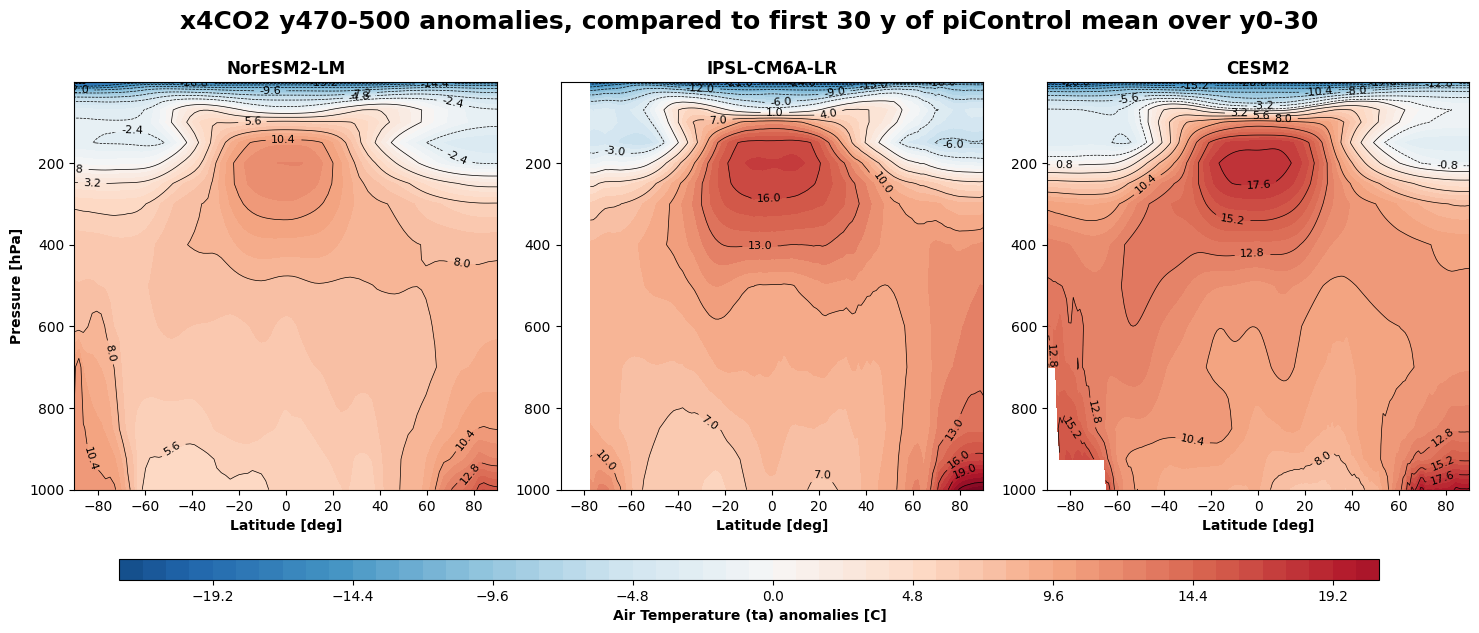

In [29]:
data_piControl_list = [diff_noresm2_470_500, diff_ipsl_470_500, diff_cesm2_470_500]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i in range(0, 3):

    if titles[i]== "NorESM2-LM":        

        lat = ta_noresm2_zonal_piControl.lat
        lev = ta_noresm2_zonal_piControl.plev/100 

    elif titles[i]== "IPSL-CM6A-LR":        

        lat = ta_ipsl_zonal_piControl.lat
        lev = ta_ipsl_zonal_piControl.plev/100 

    else:
        lat = ta_cesm2_zonal_piControl.lat
        lev = ta_cesm2_zonal_piControl.plev/100  
        
    data = data_piControl_list[i]

    #print(data)

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        vmin=-25, vmax=25
    )

    levels = im_pi.levels
    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels[::3],
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels[::3],
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Pressure [hPa]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Air Temperature (ta) anomalies [C]", fontweight='bold')

fig.suptitle("x4CO2 y470-500 anomalies, compared to first 30 y of piControl mean over y0-30", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

In [33]:
def nearest_levels(data, target_levels):
    data_vals = np.unique(data[~np.isnan(data)])
    return np.array([
        data_vals[np.argmin(np.abs(data_vals - lvl))]
        for lvl in target_levels
    ])

In [53]:
data_piControl_list = [
    ta_noresm2_zonal_piControl.values,
    ta_ipsl_zonal_piControl.values,
    ta_cesm2_zonal_piControl.values
]

data_anom_list = [
    diff_noresm2_470_500,
    diff_ipsl_470_500,
    diff_cesm2_470_500
]

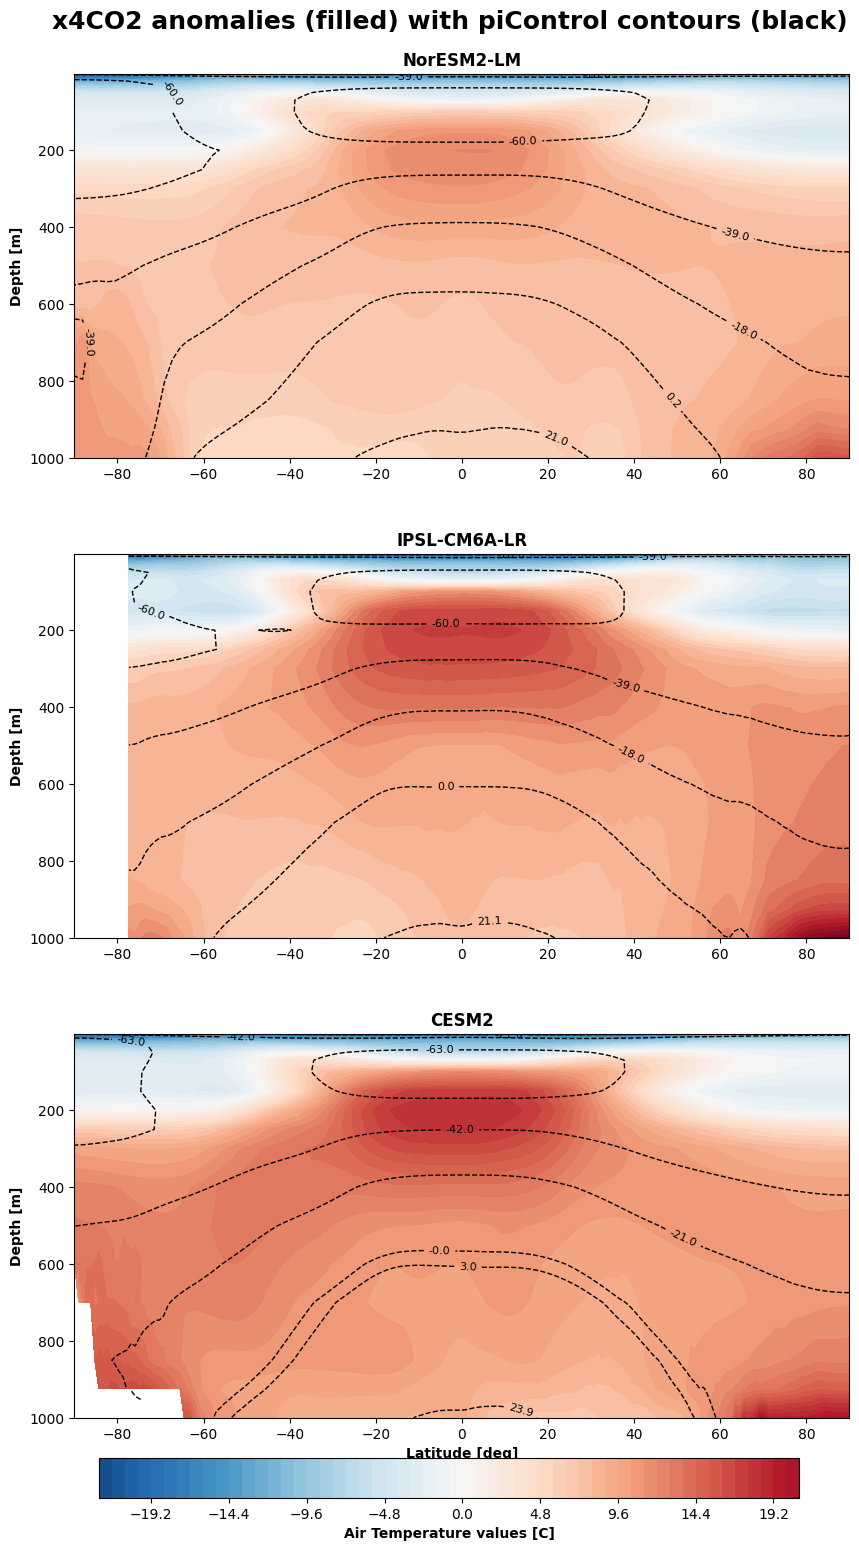

In [56]:
fig = plt.figure(figsize=(10, 16))
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i in range(3):

    if titles[i]== "NorESM2-LM":        

        lat = ta_noresm2_zonal_piControl.lat
        lev = ta_noresm2_zonal_piControl.plev/100 

    elif titles[i]== "IPSL-CM6A-LR":        

        lat = ta_ipsl_zonal_piControl.lat
        lev = ta_ipsl_zonal_piControl.plev/100 

    else:
        lat = ta_cesm2_zonal_piControl.lat
        lev = ta_cesm2_zonal_piControl.plev/100  

    data_picontrol = data_piControl_list[i]
    data_anom = data_anom_list[i]

    target_levels_pi = np.arange(-90, 40, 3)
    target_levels_anom = np.arange(-25, 25, 2)

    ax = fig.add_subplot(gs[i, 0])

    levels_pi = np.unique(nearest_levels(data_picontrol, target_levels_pi))
    levels_anom = np.unique(nearest_levels(data_anom, target_levels_anom))
    
    neg_levels_pi = levels_pi[levels_pi < 0]
    pos_levels_pi = levels_pi[levels_pi > 0]

    # ---- Line contours: piControl (black) ----
    pi_neg = ax.contour(
        lat, lev,
        data_picontrol,
        levels=neg_levels_pi[::7],
        colors="k",
        linestyles="dashed",
        linewidths=1
    )

    pi_pos = ax.contour(
        lat, lev,
        data_picontrol,
        levels=pos_levels_pi[::7],
        colors="k",
        linestyles="dashed",
        linewidths=1
    )

    neg_levels_anom = levels_anom[levels_anom < 0]
    pos_levels_anom = levels_anom[levels_anom > 0]

    # ---- Filled contours: anom ----
    im_anom = ax.contourf(
        lat, lev,
        data_anom,
        levels=60,
        cmap="RdBu_r",
        vmin=-25, vmax=25
    )

    # ---- Line contours: anom (red) ----
#    anom_neg = ax.contour(
#        lat, lev,
#        data_anom,
#        levels=neg_levels_anom, #[::7],
#        colors="k",
#        linestyles="solid",
#        linewidths=1.2
#    )

#    anom_pos = ax.contour(
#        lat, lev,
#        data_anom,
#        levels=pos_levels_anom, #[::7],
#        colors="k",
#        linestyles="solid",
#        linewidths=1.2
#    )

    ax.set_title(titles[i], fontweight="bold")
    ax.invert_yaxis()

    ax.set_ylabel("Depth [m]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

    ax.clabel(anom_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(anom_pos, inline=True, fmt="%1.1f", fontsize=8)

ax.set_xlabel("Latitude [deg]", fontweight="bold")

# ---- Horizontal colorbar ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.025])
cbar = fig.colorbar(im_anom, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Air Temperature values [C]", fontweight="bold")

fig.suptitle(
    "x4CO2 anomalies (filled) with piControl contours (black)",
    fontsize=18,
    weight="bold",
    y=0.98
)

plt.subplots_adjust(top=0.94, bottom=0.10, hspace=0.25)
plt.show()
